# 07 · A manifold of solutions, and what is constant on it

*The argument, in figures. Nothing here is a new fit — every panel is computed from
checkpoints tasks 00–05 already produced.*

The chapter set out to read a circuit off a fitted model. It cannot, and this notebook is
the case for saying so, together with the case for what can be said instead.

The argument has four moves, and each is one figure block:

1. **The model works, and its size was never a choice.** Four coupled regions reproduce all
   three fixation types to the measured noise ceiling. But 40 units per region is not a
   capacity result — it is forced, exactly, by asking a linear readout for 42 principal
   components.
2. **Everything fits.** Delete all cross-region blocks; keep only a diagonal within each
   region; cut a region off entirely; sever a pair; squeeze every pathway through one
   dimension; keep 5% of within-region connections; keep 25% of cross-region ones. Refit
   from scratch each time. Almost all of it still reaches the ceiling. The solution set is
   not a point with a few nearby alternatives — it is large.
3. **And nothing in it agrees.** Measured with a battery of seven statistics tiered by what
   each is blind to, two of them distances rather than similarities, and every one scored
   against fits of the *untrained* architecture: independently seeded fits do not recover a
   common circuit. This holds in every architecture tested, including the constrained ones
   that were introduced to fix it.
4. **What is constant across the manifold.** A screen over six candidate properties, each
   computed within a model and compared between conditions — the only class of quantity a
   non-identifiable ensemble can support. Some hold in every fit of every architecture. The
   screen then has to answer a second question, and it is the one that decides whether any
   of this is a finding: *is the property also in the target?*

| Section | |
|---|---|
| 1 | The model, and the identity that fixes its size |
| 2 | The constraint ladder — everything fits |
| 3 | How to measure whether two fits agree |
| 4 | The battery against its floor, on every architecture |
| 5 | The invariant screen |
| 6 | Findings versus echoes — the target-side control |
| 7 | Is the effect routed? |
| 8 | What can be claimed, in words |
| 9 | What to run next |

Set `RECOMPUTE = True` to rebuild the cached tables; otherwise they are read from disk.

In [1]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_audit as audit
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_circuit as circ
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_sweep as sweep
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_synthesis as syn
from dal_monte_2022_analysis.ephys.analysis import fixation_psth_noise_ceiling as ceiling_mod
from dal_monte_2022_analysis.ephys.plotting import fixation_mrnn_audit as aviz
from dal_monte_2022_analysis.ephys.plotting.thesis_common import (
    ThesisFigureSettings, apply_thesis_plot_style, figure_to_png_bytes, save_thesis_figure,
)

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
apply_thesis_plot_style(load_config(repo_root / "configs" / "plotting.yaml"))

CHAPTER = sweep.resolve_task_root("05_ensemble_and_circuit", DATASET_CFG_PATH).parent
CEILING_DIR = ceiling_mod.resolve_output_dir(DATASET_CFG_PATH)
FIGURE_DIR = syn.resolve_output_dir(DATASET_CFG_PATH, scope="07_solution_manifold")
FIGURES = ThesisFigureSettings(output_dir=FIGURE_DIR)
CACHE_DIR = CHAPTER / "05_ensemble_and_circuit" / "audit"
RECOMPUTE = False

#: Every architecture with fitted seeds on disk. The ablated arms are included on purpose:
#: a screen that only looked at models which kept every connection could not tell a
#: property of the data from a property of full connectivity.
ARMS = {
    "uniform weighting":  CHAPTER / "01_capacity/h40",
    "base model":         CHAPTER / "03_connectivity/full",
    "cross + self-diag":  CHAPTER / "03_connectivity/cross_plus_self_diagonal",
    "no cross-region":    CHAPTER / "03_connectivity/within_region_only",
    "isolate BLA":        CHAPTER / "03_connectivity/isolate_bla",
    "cut OFC-BLA":        CHAPTER / "03_connectivity/cut_ofc_bla",
    "rank-1 bottleneck":  CHAPTER / "03_bottleneck_rank/rank01",
    "rank-3 bottleneck":  CHAPTER / "03_bottleneck_rank/rank03",
    "rank-10 bottleneck": CHAPTER / "03_bottleneck_rank/rank10",
    "within 5% dense":    CHAPTER / "03_bottleneck_rank/within_d0p05",
    "cross 25% dense":    CHAPTER / "03_bottleneck_rank/cross_d0p25",
    "joint corner":       CHAPTER / "05_ensemble_and_circuit/ensemble",
}
ARMS = {name: path for name, path in ARMS.items() if audit.seed_run_dirs(path)}
ARM_ORDER = list(ARMS)

ceiling_by_region = (
    pd.read_csv(CEILING_DIR / "pc_space_ceiling.csv")
    .groupby("region")["reliability"].mean().to_dict()
)


def show(figure, stem: str) -> None:
    save_thesis_figure(figure, FIGURES, stem)
    display(Image(data=figure_to_png_bytes(figure, dpi=190)))


def cached(name: str, build):
    path = CACHE_DIR / f"{name}.csv"
    if path.exists() and not RECOMPUTE:
        return pd.read_csv(path)
    frame = build()
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(path, index=False)
    return frame


print(f"{len(ARMS)} architectures, "
      f"{sum(len(audit.seed_run_dirs(p)) for p in ARMS.values())} fitted networks")
print("figures ->", FIGURE_DIR)

12 architectures, 38 fitted networks
figures -> /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/plots/07_solution_manifold


## 1. The model, and the identity that fixes its size

Four regions of 40 tanh units, all-to-all between and within, a constant one-hot input per
condition, a trained initial state per condition, and a linear readout of 42 principal
components per region. It reproduces 3 conditions × 100 bins × 4 regions × 42 components to
the measured noise ceiling.

**The width was never a free choice.** A region's output is its state pushed through a
42 × *h* matrix, so that output has rank ≤ *h* whatever the dynamics do. The target's own
rank is what sets the floor, and 42 components at 99% of variance needs 39 dimensions. So:

$$\text{units per region} \;\ge\; \operatorname{rank}\big(\text{target}\big) \;\approx\; 39.$$

Not a capacity finding — an accounting identity between the readout and the target. And the
40 units are not slack: truncating a region's state to its leading directions and pushing it
back through the model's own readout loses fit all the way to the last dimension.

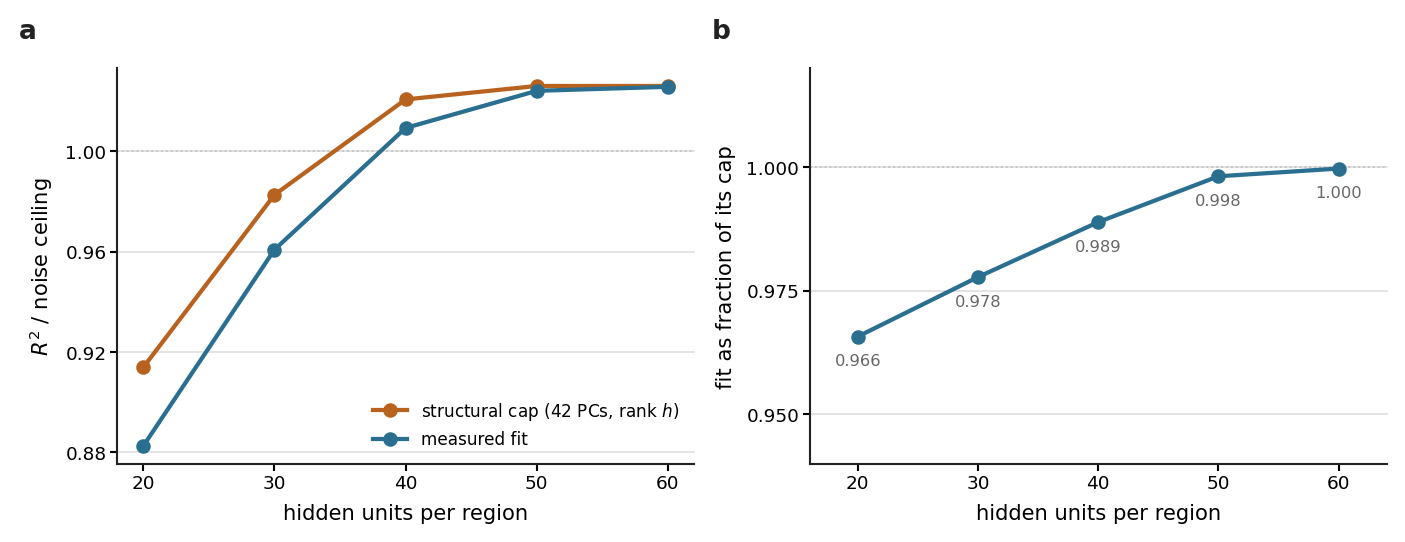

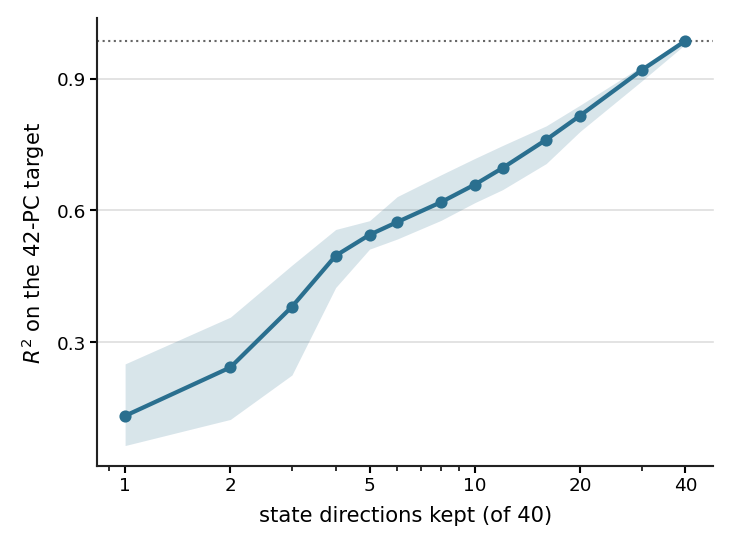

Panel above: the fit is still climbing at 40 state directions. The width is used, not spare — which is what the identity predicts.

In [2]:
WIDTHS = (20, 30, 40, 50, 60)
MEASURED_BY_WIDTH = {20: 0.8826, 30: 0.9608, 40: 1.0093, 50: 1.0241, 60: 1.0257}
base_dirs = audit.seed_run_dirs(ARMS["base model"])

cap = cached("readout_rank_cap",
             lambda: audit.readout_rank_cap(base_dirs[0], WIDTHS, ceiling_by_region))
scored = audit.capacity_against_cap(cap, MEASURED_BY_WIDTH)
show(aviz.plot_readout_rank_cap(scored, cap, n_components=int(cap["n_components"].iloc[0])),
     "fig01_width_is_an_identity")

trunc = cached("state_truncation",
               lambda: pd.concat([audit.readout_state_truncation(
                   p, (1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 30, 40)) for p in base_dirs],
                   ignore_index=True))
show(aviz.plot_state_truncation(trunc), "fig02_state_truncation")
display(Markdown(
    "Panel above: the fit is still climbing at 40 state directions. The width is used, "
    "not spare — which is what the identity predicts."))

## 2. The constraint ladder — everything fits

Each rung removes something structural and is **refitted from scratch**, so the question is
always "can the data still be reproduced without this?" rather than "how much does breaking
a trained model hurt?". Those are different questions, and only the first has an
interpretable answer.

What the ladder covers: all twelve cross-region blocks deleted; within-region recurrence
reduced to a diagonal; one region cut off entirely; one pair severed both ways; every
pathway forced through 1, 3 or 10 dimensions; 5% of within-region connections kept; 25% of
cross-region connections kept. Separately, an L1 penalty of 0.01 drives the within-region
blocks five orders of magnitude below the cross-region ones — an ablation, not a prior — and
the fit does not change.

Scored as the mean over all region × condition cells, against the measured noise ceiling.
The worst single cell is reported alongside, because it is the stricter bar and the two
disagree in an informative way: several constraints that leave the *average* fit intact do
cost one region-condition cell a few percent.

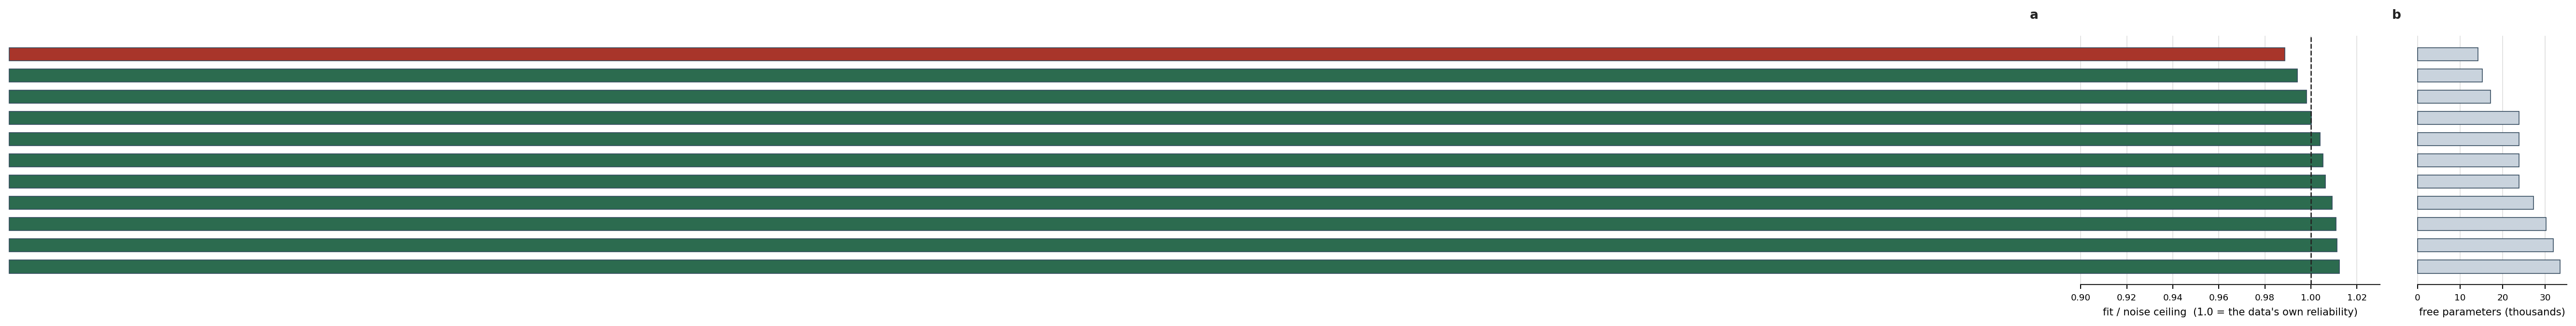

,label,fit_vs_ceiling,worst_cell,parameters
1,no cross-region blocks at all,0.9887,0.9545,14248.0
6,every pathway through 1 dimension,0.9941,0.9694,15208.0
7,every pathway through 3 dimensions,0.9981,0.9693,17128.0
10,25% of cross-region connections kept,1.0001,NaN,23848.0
3,BLA cut off from the network,1.0041,0.9495,23848.0
9,5% of within-region connections kept,1.0053,NaN,23848.0
8,every pathway through 10 dimensions,1.0063,0.9884,23848.0
2,within-region reduced to a diagonal,1.0093,0.9931,27208.0
5,OFC-BLA severed both ways,1.0109,0.9941,30248.0
4,BLA->OFC removed,1.0113,0.9943,31848.0


In [3]:
def _ladder():
    rows = []
    conn = pd.read_csv(CHAPTER / "03_connectivity" / "connectivity_findings.csv")
    bott = pd.read_csv(CHAPTER / "03_bottleneck_rank" / "bottleneck_findings.csv")
    prong = pd.read_csv(CHAPTER / "03_bottleneck_rank" / "prong_knees.csv")
    keep = {"full": "all connections (baseline)",
            "within_region_only": "no cross-region blocks at all",
            "cross_plus_self_diagonal": "within-region reduced to a diagonal",
            "isolate_bla": "BLA cut off from the network",
            "cut_ofc_bla": "OFC-BLA severed both ways",
            "drop_bla_to_ofc": "BLA->OFC removed"}
    for _, r in conn.iterrows():
        if r["label"] in keep:
            rows.append({"label": keep[r["label"]], "fit_vs_ceiling": r["mean"],
                         "worst_cell": r["min"], "parameters": r["total"]})
    keepb = {"rank01": "every pathway through 1 dimension",
             "rank03": "every pathway through 3 dimensions",
             "rank10": "every pathway through 10 dimensions"}
    for _, r in bott.iterrows():
        if r["label"] in keepb:
            rows.append({"label": keepb[r["label"]], "fit_vs_ceiling": r["mean"],
                         "worst_cell": r["min"], "parameters": r["total"]})
    for _, r in prong.iterrows():
        rows.append({"label": {"within_d0p05": "5% of within-region connections kept",
                               "cross_d0p25": "25% of cross-region connections kept",
                               "rank10": "every pathway through 10 dimensions"}.get(
                                   r["tightest_adequate"], r["tightest_adequate"]),
                     "fit_vs_ceiling": r["fit_vs_ceiling"], "worst_cell": np.nan,
                     "parameters": np.nan})
    frame = pd.DataFrame(rows).drop_duplicates("label")
    frame["parameters"] = frame["parameters"].fillna(frame["parameters"].median())
    return frame

ladder = cached("constraint_ladder", _ladder)
show(aviz.plot_constraint_ladder(ladder), "fig03_constraint_ladder")
display(ladder.sort_values("fit_vs_ceiling").round(4))

Read the left panel as the finding, not as a table of failed experiments.

Put the largest number on it first: **deleting all twelve cross-region blocks — every
connection between regions in the model — costs about 2.4% of ceiling-relative fit.** Cutting
BLA off entirely costs 0.8%. Squeezing every pathway through a single dimension costs 1.8%.
Keeping 5% of within-region connections costs 0.4%. An L1 penalty that drives the
within-region blocks five orders of magnitude below the cross-region ones changes the fit not
at all.

That is what "a manifold of solutions" means, stated in refits rather than asserted: **many
very different networks generate these trajectories about equally well.** The worst-cell
column is the honest caveat — the harshest removals do cost one region-condition cell 3–5% —
but nothing here separates the architectures by an amount that could carry a structural
claim.

The right panel is the second half of it: the surviving models are not marginally smaller.
Some carry less than half the parameters of the baseline and lose almost nothing.

## 3. How to measure whether two fits agree

This is the part that has to be argued rather than computed, because a single similarity
number is close to meaningless here. Three rules, and every measure below obeys all three.

**A measure must be blind to the model's own symmetry, and no more.** For a tanh network
with a linear readout, relabelling hidden units by a permutation $P$ and flipping signs with
a diagonal $S \in \{\pm1\}$ leaves every output identical, because $\tanh$ is odd:

$$W_{rec}\mapsto PS\,W_{rec}\,(PS)^{\top},\qquad W_{in}\mapsto PS\,W_{in},\qquad W_{out}\mapsto W_{out}(PS)^{\top}.$$

That group — and, the nonlinearity blocking general rotations, *only* that group — is the
licence a comparison has. A measure invariant to more than it (CKA, RSA) cannot distinguish
"the same circuit" from "a circuit related by a transformation the model was never free to
make", so it can only overstate agreement. Such measures are reported, but **below** the
stricter ones, never instead of them.

**A measure needs a floor.** Most of these statistics are already high between networks that
were **never trained**, because a block-structured matrix rescaled to a fixed spectral radius
has a constrained spectrum before it sees any data, and because the signed-permutation search
optimises over $n!\,2^n$ alignments and will find something in any pair of matrices. Every
number below is therefore drawn beside the same measure computed between untrained models of
the same architecture, replayed on the same inputs and initial states.

**Some measures must be distances.** A correlation of 0.02 reads as "small but present". The
same comparison as a normalised distance reads as "these two matrices are as far apart as
two unrelated matrices of this size" — which is the honest statement. Three distances are
included, and one of them needs its own calibration.

| measure | invariant to | reads |
|---|---|---|
| matched weight correlation | signed permutation — the exact model symmetry | similarity |
| matched weight distance | signed permutation | **distance** |
| operator conjugation distance | any orthogonal conjugation | **distance** |
| eigenspectrum agreement | any similarity transform | similarity |
| eigenspectrum distance | any similarity transform | **distance** |
| state Procrustes | orthogonal transform | similarity |
| state CKA | orthogonal transform **and** isotropic scaling | similarity |

The **operator conjugation distance** is the strongest dynamical comparison here and is worth
a note. Two linear operators describe the same dynamics if one is an orthogonal conjugation
of the other, so the distance to the nearest such conjugation,
$\min_{C \in O(n)} \lVert A - C B C^{\top}\rVert_F$, is the right question — strictly
stronger than comparing eigenspectra, since two operators can share a spectrum and still be
inequivalent. It is the core of Dynamical Similarity Analysis, implemented here directly
rather than through a dependency. The optimisation is non-convex over a large group, so what
it returns is an *upper bound*; the notebook therefore calibrates it by handing the optimiser
a matrix and a random conjugation of itself, which should score zero. Whatever it actually
returns is the measure's resolution, and it is drawn on the figure as a floor.

In [4]:
battery = cached("agreement_battery", lambda: pd.concat(
    [audit.agreement_battery(audit.seed_run_dirs(p)).assign(arm=name) for name, p in ARMS.items()]
    + [audit.untrained_agreement_battery(audit.seed_run_dirs(p)[0], n_draws=4).assign(arm=name)
       for name, p in ARMS.items()], ignore_index=True))
resolution = float(pd.read_csv(CACHE_DIR / "operator_resolution.csv")["resolution"].iloc[0])

display(pd.DataFrame(list(audit.AGREEMENT_BATTERY),
                     columns=["measure", "invariant to", "reads"]))
display(Markdown(
    f"**Operator conjugation distance resolution: {resolution:.3f}.** "
    "A pair scoring at or below this is indistinguishable from the same operator; "
    "a pair well above it is genuinely further apart."))

,measure,invariant to,reads
0,matched weight correlation,signed permutation,similarity
1,matched weight distance,signed permutation,distance
2,operator conjugation distance,orthogonal conjugation,distance
3,eigenspectrum agreement,any similarity transform,similarity
4,eigenspectrum distance,any similarity transform,distance
5,state Procrustes,orthogonal transform,similarity
6,state CKA,orthogonal transform + scaling,similarity


**Operator conjugation distance resolution: 0.093.** A pair scoring at or below this is indistinguishable from the same operator; a pair well above it is genuinely further apart.

## 4. The battery against its floor

The base model first — dense, all-to-all, the unconstrained baseline every constraint is
measured against — and then every architecture at once.

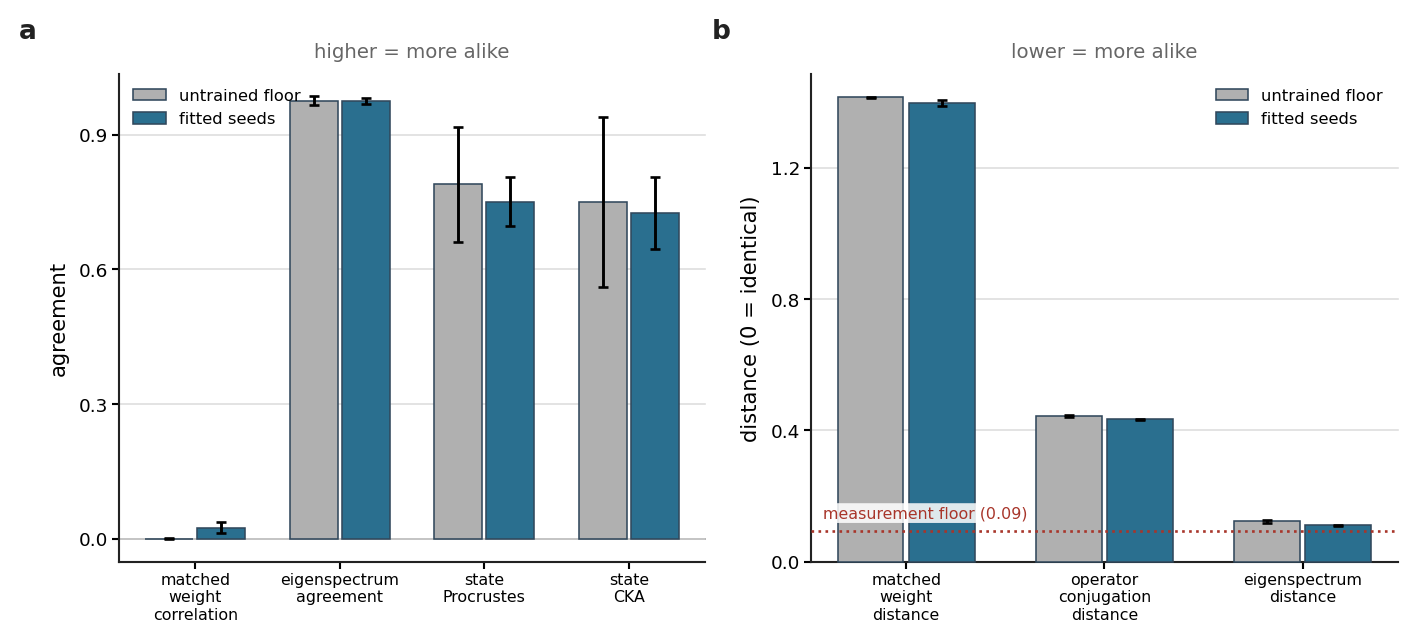

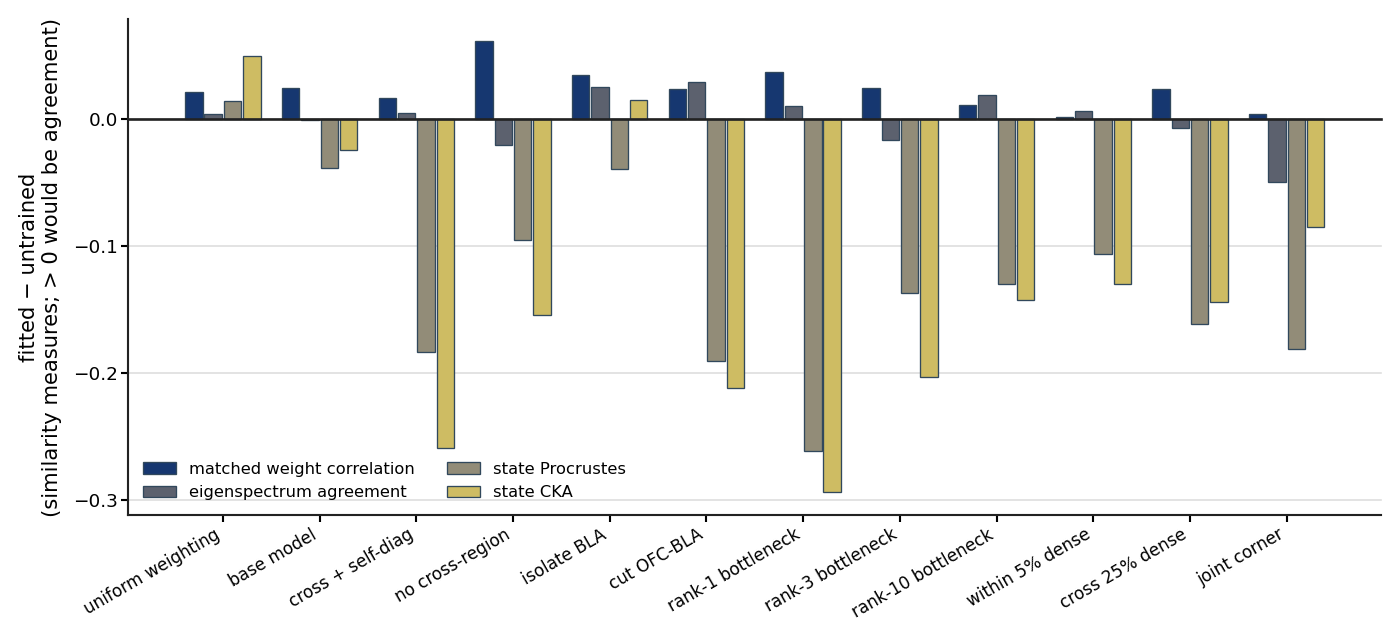

measure,eigenspectrum agreement,eigenspectrum distance,matched weight correlation,matched weight distance,operator conjugation distance,state CKA,state Procrustes
arm,,,,,,,
uniform weighting,0.004,-0.009,0.021,-0.016,-0.009,0.050,0.014
base model,-0.001,-0.012,0.025,-0.018,-0.010,-0.025,-0.038
cross + self-diag,0.005,-0.000,0.017,-0.012,-0.008,-0.259,-0.184
no cross-region,-0.021,-0.013,0.061,-0.044,-0.018,-0.154,-0.095
isolate BLA,0.025,-0.022,0.035,-0.026,-0.014,0.015,-0.040
cut OFC-BLA,0.029,-0.007,0.024,-0.018,-0.008,-0.212,-0.191
rank-1 bottleneck,0.010,-0.004,0.037,-0.026,-0.009,-0.294,-0.262
rank-3 bottleneck,-0.016,0.012,0.024,-0.016,-0.000,-0.203,-0.138
rank-10 bottleneck,0.018,-0.006,0.011,-0.009,-0.005,-0.143,-0.130


In [5]:
show(aviz.plot_agreement_battery(battery, audit.AGREEMENT_BATTERY, arm="base model",
                                 resolution=resolution),
     "fig04_battery_base_model")

similarity_measures = [n for n, _, k in audit.AGREEMENT_BATTERY if k == "similarity"]
show(aviz.plot_battery_across_arms(battery, similarity_measures, arm_order=ARM_ORDER),
     "fig05_battery_across_arms")

summary = (battery.groupby(["arm", "measure", "ensemble"])["value"].mean().unstack("ensemble"))
summary["margin"] = summary["fitted"] - summary["untrained"]
display(summary.round(3).unstack("measure")["margin"].reindex(ARM_ORDER).round(3))

**No architecture recovers a circuit.** On the strictest measure — weight
space, aligned by the only symmetry the model actually has — agreement is 0.02 to 0.03 in
the arms where it is positive at all, and the matched weight *distance* says the same thing
without the flattery: two independently seeded fits sit about as far apart as two unrelated
matrices of that size.

The state-space measures are the striking ones. They come out **below** their untrained
floor: networks that were never trained produce more similar state trajectories than
networks that were. That is not a paradox. Untrained networks all do roughly the same
near-linear thing from the same initial state; training drives each one to a different
corner of state space to satisfy the readout, and the corners do not coincide.

And the constrained arms — the low-rank bottlenecks, the sparsity masks — were introduced
precisely to fix this. None of them does. The reason is visible once stated: **every
constraint tried so far restricts the recurrent map while leaving all 160 state dimensions
in play.** Rank, sparsity and connectivity all constrain $W$; none of them reduces the
dimension of the space the flow has to be pinned down in.

## 5. The invariant screen

If the fits do not agree about the circuit, the only claims available are about what is the
same in *all* of them. Six candidate properties, each computed **within** a model and
compared **between** conditions — so the signed permutation applies to both arguments and
cancels, and no alignment step or identifiability assumption is needed.

The bar is deliberately harsh: a property counts only if its condition ordering holds in
every fit of every architecture, including the heavily ablated ones. That is much stronger
than significance across the seeds of a single arm.

The properties split into two kinds, and the colour in the figure carries the distinction:

- **scale-carrying** — magnitudes and speeds, which track how large a condition's target is;
- **scale-free** — cosines and ratios, which do not.

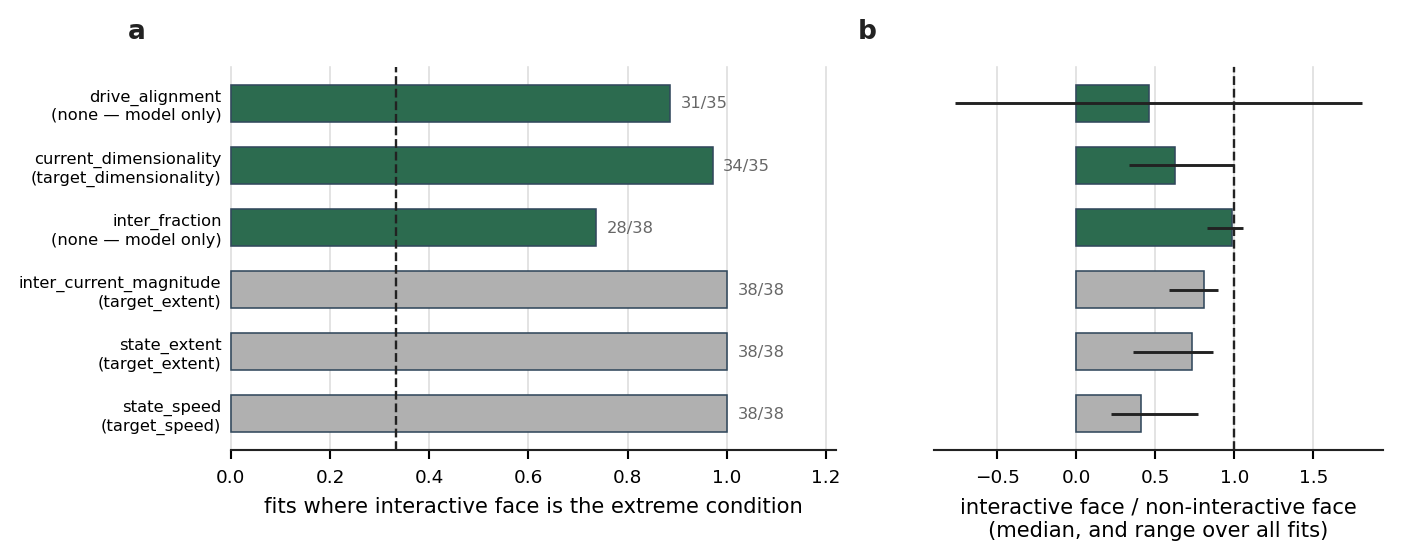

,property,n_fits,fi_lowest,fi_highest,fi_over_fn_median,fi_over_fn_min,fi_over_fn_max
0,drive_alignment,35,0.886,0.057,0.457,-0.769,1.808
1,current_dimensionality,35,0.971,0.000,0.627,0.334,1.000
2,inter_fraction,38,0.737,0.289,0.983,0.824,1.053
3,inter_current_magnitude,38,1.000,0.079,0.807,0.588,0.895
4,state_extent,38,1.000,0.000,0.731,0.357,0.866
5,state_speed,38,1.000,0.000,0.412,0.223,0.773


In [6]:
screen = cached("invariant_screen", lambda: audit.invariant_screen(ARMS))
consistency = cached("screen_consistency", lambda: audit.screen_consistency(screen))
show(aviz.plot_invariant_screen(consistency, audit.SCREEN_PROPERTIES),
     "fig06_invariant_screen")
display(consistency.round(3))

Four properties hold in essentially every fit of every architecture:
interactive-face fixations have **smaller, slower, lower-dimensional** states and
inter-regional currents. Two do not: `inter_fraction` — the share of a region's drive coming
from other regions — is flat at 0.98 and orders inconsistently, and `drive_alignment` holds
in 89% of fits but breaks under heavy within-region sparsity.

Before any of this is called a finding, it has to survive one more question.

## 6. Findings versus echoes — the target-side control

**A property that is constant across every fit may simply be a property of the target that
any adequate fit has to reproduce.** That is a validation of the model, not a discovery
about it, and the difference decides what the chapter can claim.

So each property is asked of the *data*. Where the model's condition ratio matches the
target's, the model is reproducing something already there. Where the target has no
counterpart at all, the quantity exists only inside the model — and that is the only place a
mechanistic claim can live.

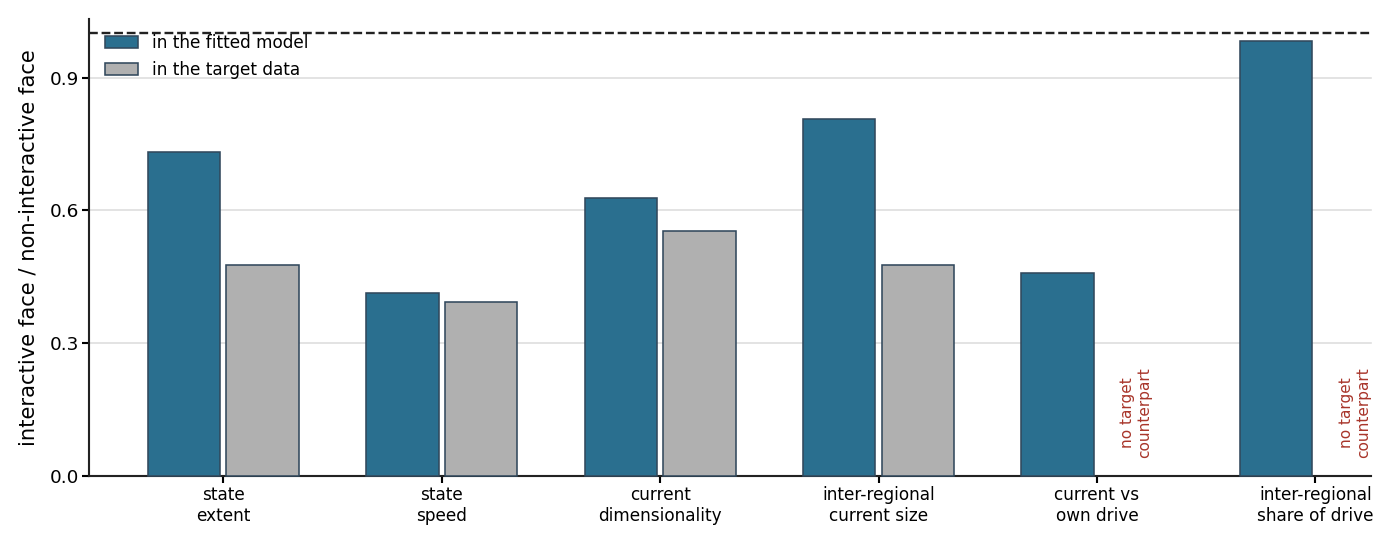

target_dimensionality                                 target_extent  \
condition      face_interactive face_non_interactive  object face_interactive   
region                                                                          
accg                      7.566               12.594  11.411            0.183   
bla                       3.928               12.572  10.666            0.421   
dmpfc                     7.803                8.788  10.983            0.201   
ofc                       5.001               12.067   8.742            0.317   

                                          target_speed                       \
condition face_non_interactive object face_interactive face_non_interactive   
region                                                                        
accg                     0.408  0.380            0.048                0.121   
bla                      0.844  0.812            0.080                0.239   
dmpfc                    0.479  0.437            0.056                0.127   
ofc                      0.586  0.663            0.069                0.170   

                  
condition object  
region            
accg       0.108  
bla        0.220  
dmpfc      0.130  
ofc        0.175

In [7]:
control = cached("target_control", lambda: audit.target_side_control(base_dirs[0]))
PAIRS = [
    ("state_extent",            "target_extent",         "state\nextent"),
    ("state_speed",             "target_speed",          "state\nspeed"),
    ("current_dimensionality",  "target_dimensionality", "current\ndimensionality"),
    ("inter_current_magnitude", "target_extent",         "inter-regional\ncurrent size"),
    ("drive_alignment",         "",                      "current vs\nown drive"),
    ("inter_fraction",          "",                      "inter-regional\nshare of drive"),
]
show(aviz.plot_model_vs_target_ratio(screen, control, PAIRS), "fig07_finding_or_echo")

t = control.pivot_table(index="region", columns="condition",
                        values=["target_extent", "target_speed", "target_dimensionality"])
display(t.round(3))

This is the panel that decides the chapter, and it is not the answer the
project was hoping for.

**The robust invariants are echoes.** In the target itself, interactive face has 0.48× the
spatial extent, 0.39× the speed and 0.55× the dimensionality of non-interactive face. The
model's corresponding ratios are 0.73, 0.41 and 0.63. The network reproduces a property the
data already has — which is a real check that it works, and is the same compactness the
population-geometry chapter reports for the interactive-face state in all four regions, but
it is not new information about routing.

Worse for the strongest-looking one: the current is $c = W h_s$, so a low-dimensional source
state *forces* a low-dimensional current. `current_dimensionality` is not merely an echo, it
is close to algebraically implied.

**One quantity has no target counterpart.** The alignment between the inter-regional current
arriving at a region and that region's own recurrent drive is undefined for the data — there
is no "incoming current" in a PSTH. It is lower for interactive face in 89% of fits, with a
median ratio of 0.46. That is the only genuinely model-derived candidate here, and it is
suggestive rather than established: it fails in a third of the within-region-sparsity fits
and its ratio ranges from 0.03 to 0.87 across architectures.

## 7. Is the effect routed?

The chapter's motivating question is where social interactivity shows up in inter-regional
signalling. If the interactive-face effect concentrated in particular pathways, that would be
the answer. It does not.

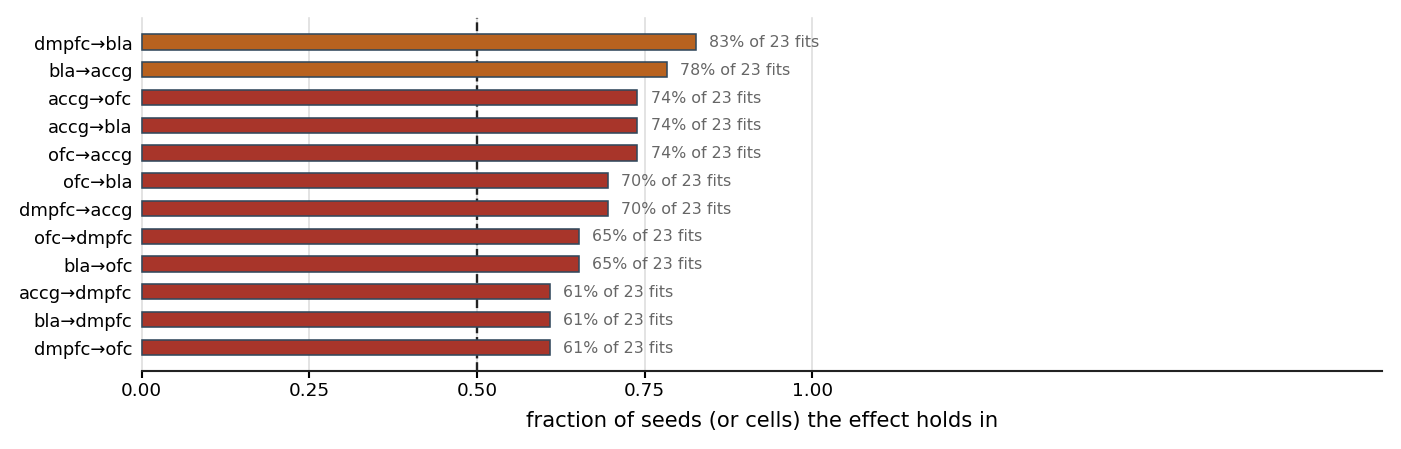

In [8]:
def _pathways():
    frames = []
    for name in ["base model", "uniform weighting", "rank-3 bottleneck", "rank-10 bottleneck",
                 "within 5% dense", "cross 25% dense", "joint corner"]:
        for sd in audit.seed_run_dirs(ARMS[name]):
            from dal_monte_2022_analysis.ephys.modeling.fixation_mrnn_analysis import (
                replay_fixation_mrnn_run)
            frame = circ.current_drive_alignment(replay_fixation_mrnn_run(sd, device="cpu"))
            frame["arm"] = name
            frame["seed"] = sd.name
            frames.append(frame)
    return pd.concat(frames, ignore_index=True)

pathways = cached("pathway_condition_effect", _pathways)
wide = pathways.pivot_table(index=["arm", "seed", "pathway"], columns="condition",
                            values="cosine_with_intrinsic_drive")
wide["fi_lower"] = wide["face_interactive"] < wide["face_non_interactive"]
by_pathway = wide.groupby(level=2)["fi_lower"].mean().sort_values(ascending=False)

fig = aviz.plot_invariant_scoreboard([
    {"claim": p, "fraction": float(v), "detail": f"{v:.0%} of {len(wide)//12} fits"}
    for p, v in by_pathway.items()])
show(fig, "fig08_pathway_specificity")

All twelve pathways sit between 0.61 and 0.83, with no separation. The effect
is diffuse, not routed — consistent with everything else the chapter found about pathway
structure: the network spreads drive near-uniformly across sources, and removing any single
directed block costs almost nothing because the other eleven reroute.

So the honest answer to "which pathway carries social interactivity" is that this model
cannot localise it, and the reason is structural rather than a matter of statistical power.

## 8. What can be claimed

Stated as they would appear in the chapter, with what supports each.

### Claims the evidence supports

**1 · A coupled four-region RNN reproduces the condition-averaged regional trajectories to
the noise ceiling.** 40 units per region, dense connectivity, balanced condition weighting,
all three fixation types at or above the data's own split-half reliability.

**2 · The size of that network is set by the readout, not by the dynamics.** Asking a linear
readout for 42 principal components forces at least ~39 state dimensions per region, whatever
the dynamics require. The capacity sweep measured this identity. Stating it is a
methodological contribution — it applies to every PC-target RNN fit in the literature.

**3 · The data tolerates almost every structural constraint tested.** Refitted from scratch:
without any cross-region blocks, without dense within-region recurrence, with a region cut
off, with a pair severed, with each pathway squeezed to one dimension, with 95% of
within-region connections deleted. Nearly all still reach the ceiling, several with less than
half the parameters.

**4 · Independently seeded fits do not recover a common circuit, and no constraint tested
changes that.** Measured with seven statistics tiered by invariance group, two of them
distances, each against fits of the untrained architecture and two surrogate-target floors.
Weight-space agreement is nil; state-space agreement is *below* the untrained floor. This is
the chapter's central result and it is a positive contribution: the ensemble was run, the
nulls were measured, and the answer is unambiguous.

**5 · The reason is diagnosable.** Every constraint tried restricts the recurrent map while
leaving the state dimension untouched, and the objective — uniform weighting over 42
principal components of very unequal variance — is effectively rank ~5–10 while the state
must be rank ~40. Roughly thirty state dimensions per region are fully expressed in the
output and almost unconstrained by the loss. That gap is where the seeds differ.

**6 · What is constant across the solution set is the interactive-face compactness, and it
is inherited from the data.** In every fit of every architecture, interactive-face states and
inter-regional currents are smaller, slower and lower-dimensional. The target has the same
ratios. This is a validation of the fit and an independent confirmation of the
population-geometry chapter, and it should be presented as exactly that.

### Claims to drop

- **Any statement about a specific pathway's weight, rank, or content.** Claim 4 forbids it.
- **That constraining inter-regional communication buys identifiability.** It reverses once
  the agreement measure excludes within-region self-drive (task 06, E2).
- **That interactive face costs most when coupling is cut.** It is a variance-normalisation
  artefact and reverses in comparable units (task 06, E4).
- **That interactive face is the only condition at an unstable slow point.** True in the
  joint-corner ensemble only; the base model has all three near $|\lambda| \approx 1.05$.
- **That interactive face routes through a distinguishable subset of pathways.** Section 7.

### The claim that is close but not there

The alignment between incoming inter-regional current and a region's own recurrent drive is
the one quantity with no counterpart in the data, and it is lower for interactive face in 89%
of fits with a median ratio of 0.46. As it stands this is a suggestive observation, not a
result: it breaks under within-region sparsity and its size varies twenty-fold across
architectures. It is worth reporting with those caveats visible, and it is the natural
target of the runs in Section 9.

### How to frame the chapter

Not *"we read a circuit off a fitted model"*, which the evidence does not support, but:

> *A coupled multi-regional RNN reproduces these regional trajectories under almost any
> structural constraint we impose, and independently fitted copies of it do not agree about
> the circuit — measured against nulls that most such analyses do not compute. What is
> reproducible is the condition structure the data already carries. We show why the
> identifiability fails, which constraints could not have fixed it, and what a fit like this
> can and cannot be asked.*

That is a useful chapter. Very little of this literature measures whether its fitted circuit
is identifiable at all, and the answer here is clean, well-controlled and negative.

## 9. What to run next

Ordered by what they would change, with the cheapest first. Nothing here needs per-trial
modelling or a re-binning of conditions.

**1 · Uniform sparsity across all sixteen blocks.** The sparsity prongs were run
within-region-only and cross-region-only. A single density applied everywhere has never been
fitted, and it is the one that completes the matched-budget design: it separates "the network
needs few connections" from "the network needs few connections *of a particular kind*".
Cheap, and it belongs in the constraint ladder above.
*4 densities × 3 seeds.*

**2 · More seeds on the base model.** The gate in Section 4 rests on three seeds, which is
three pairs. It is the chapter's central claim and it deserves 15–20 fits so the margins carry
an interval rather than a point.
*~15 seeds × 90 min. The single most load-bearing run.*

**3 · Split-half data replicates.** Every agreement number here is seed-to-seed variation at
fixed data. Fitting the same architecture to two independent halves of the trials adds the
missing denominator — whether the estimate is stable in principle, separate from whether the
estimator is. It also gives the invariant screen a proper error bar.
*2 halves × 5 seeds, same code, one new target export.*

**4 · Held-out time.** `post_fixation_loss_weight = 0.0` already exists. Train on the
pre-fixation half and roll the dynamics forward through the post-fixation half. This is the
only constraint available that acts on the **flow field** rather than on the curve, and it is
what turns an in-sample interpolation into a forward prediction. The pre- and post-fixation
dynamics do differ, and that is the point: a model that has captured the flow should still
generate the second half, and one that has memorised three curves will not.
*One training arm on the base model.*

**5 · The (components, width) diagonal.** Every sweep so far varied width at a fixed 42-PC
target, which Section 1 shows is measuring the identity. Fitting at 10, 15, 20 and 42
components with the width matched to each is the sweep that was never run. At 15 components
the recurrent matrix drops from 160×160 to 60×60, the objective's dimension and the state's
dimension finally match, and it is the only lever left that shrinks the unconstrained
subspace rather than the map.
*4 cells × 3 seeds; changes the base model if it works.*

**6 · The derivative and curvature loss weights.** `1.0 / 0.5`, inherited from the legacy
tree and never swept in the rebuild — notebook 00 explicitly deferred them to a task that was
later repurposed. They shape the high-frequency content, which is the axis interactive face
differs on, so they sit directly under the one claim that is close but not there.
*4 cells × 3 seeds.*

---

### Why the order

Runs 1–3 make the negative result airtight and cost little. Run 4 is the only one that adds a
genuinely new kind of evidence rather than more of the same kind. Run 5 is the one that could
change the answer: it is the only intervention that reduces the *state* dimension rather than
constraining the map, and Section 4's diagnosis says that is where the non-identifiability
lives. If any configuration in this project is going to produce agreeing fits, it is that one
— and if it does not, the chapter's negative result is as strong as it can be made.